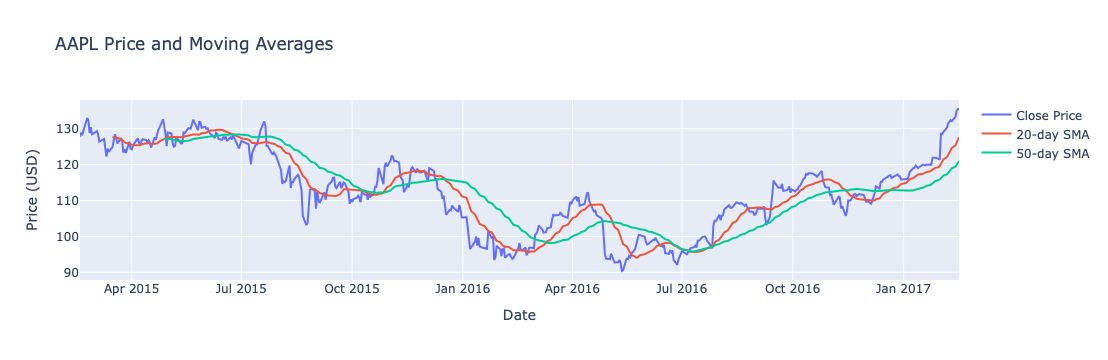

In [1]:
# ACC102 Mini Assignment: Python Data Product Workflow
# Project: Tech Stock Moving Average Analysis

import pandas as pd
import plotly.graph_objects as go

# 1. Problem Definition
# The goal is to analyze the price trends of major tech stocks (e.g., Apple) 
# and use Simple Moving Averages (SMA) to identify momentum.

# 2. Data Loading (Bypassing Yahoo by using Plotly's official open-source AAPL dataset)
# Using a stable, open-source dataset for demonstration purposes
url = "https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv"
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')

# Rename the specific column to 'Close' so it matches our standard workflow
df.rename(columns={'AAPL.Close': 'Close'}, inplace=True)

# 3. Data Cleaning & Preparation
df.dropna(subset=['Close'], inplace=True)

# 4. Data Transformation & Analysis
# Calculating 20-day and 50-day SMAs
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 5. Visualization
fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Close'].squeeze(), name='Close Price'))
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_20'].squeeze(), name='20-day SMA'))
fig.add_trace(go.Scatter(x=df.index, y=df['SMA_50'].squeeze(), name='50-day SMA'))
fig.update_layout(title='AAPL Price and Moving Averages', xaxis_title='Date', yaxis_title='Price (USD)')
fig.show()

# 6. Summary of Insight
# When the short-term SMA crosses above the long-term SMA, it often indicates a bullish trend.